# 生长曲线分析（新）

## README

## 1. 数据读取

读取4栋2单元数据

In [1]:
import pandas as pd
from feed_analysis.config.path import PATH_DATA, PATH_FEED_PROCESSED
from feed_analysis.config.coding_schema import STD_HEADER_NAME
from feed_analysis.feed_pipeline.utils.age import recalibrate_age

# # 更新日龄
# recalibrate_age(PATH_FEED_PROCESSED/'育肥4-2_column.parquet', reference_date='2025-8-25', reference_age=23)         # 根据杨乐乐主管1.4提供信息
# recalibrate_age(PATH_FEED_PROCESSED/'育肥4-2_build.parquet', reference_date='2025-8-25', reference_age=23)         # 根据杨乐乐主管1.4提供信息

# 读取喂食量数据 
df_42_col = pd.read_parquet(PATH_FEED_PROCESSED/'育肥4-2_column.parquet', engine='pyarrow')
df_42_build = pd.read_parquet(PATH_FEED_PROCESSED/'育肥4-2_build.parquet', engine='pyarrow')

# 读取存栏量数据
df_42_num = pd.read_excel(PATH_DATA / 'ori' / '育肥4-2单元存栏数.xlsx', header=3).rename(columns=STD_HEADER_NAME).sort_values(by=['Date'])
df_42_num['Date'] = pd.to_datetime(df_42_num['Date']).dt.date

# 计算头均值
df_42_build['stock_num'] = df_42_build['Date'].map(df_42_num.set_index('Date')['stock_num'])
df_42_build.dropna(subset=['stock_num'], inplace=True)
df_42_build['avg_food_kg'] = df_42_build['food_total_kg'] / df_42_build['stock_num']

# 插补缺失值
from feed_analysis.feed_pipeline.utils.interpolate import interpolation
df_42_build = interpolation(df_42_build, index_col='age', )

总趋势变化

In [4]:
from feed_analysis.visualization.line_plot import line_dynamic_single
line_dynamic_single(df_42_build, 'avg_food_kg', '育肥4-2单元料头均值', color='red')

### log-log 回归（best model）

In [15]:
from xml.parsers.expat import model
import numpy as np
import statsmodels.api as sm
from sklearn.preprocessing import PolynomialFeatures
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib import font_manager
CN_font = font_manager.FontProperties(fname='C:/Windows/Fonts/simhei.ttf')

# 线性插值

df = df_42_build.copy()
X = df[['age']].copy()
X['age'] = np.log(X['age'] + 1e-6)
X = X[['age']]  

y = df['avg_food_kg']
y_log = np.log1p(y)  # 对数转换

# 生成多项式特征（degree=2）
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X)

# 标准化
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_poly_scaled = scaler.fit_transform(X_poly)

# statsmodels 回归
X_poly_sm = sm.add_constant(X_poly_scaled)
model_poly = sm.OLS(y_log, X_poly_sm).fit()
print(model_poly.summary())

pred = model_poly.get_prediction(X_poly_sm)
pred_summary = pred.summary_frame(alpha=0.15)
print(model_poly.summary())

smearing = np.mean(np.exp(model_poly.resid))

df["food_fit"] = smearing * np.expm1(pred_summary["mean"])
df["ci_lower"] = smearing * np.expm1(pred_summary["mean_ci_lower"])
df["ci_upper"] = smearing * np.expm1(pred_summary["mean_ci_upper"])

df["pred_lower_food"] = smearing * np.expm1(pred_summary["obs_ci_lower"])  # 预测区间下界
df["pred_upper_food"] = smearing * np.expm1(pred_summary["obs_ci_upper"])  # 预测区间上界

# 输出评估指标
# Pseudo R-squared calculation
y_true = df['avg_food_kg'].values
y_pred = df['food_fit'].values  # 已经 expm1 + smearing 后的

ss_res = np.sum((y_true - y_pred) ** 2)
ss_tot = np.sum((y_true - y_true.mean()) ** 2)

r2_orig = 1 - ss_res / ss_tot
print("Pseudo R² (original scale):", r2_orig)
print("Residual variance (log-space):", np.var(model_poly.resid))

rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
mae = np.mean(np.abs(y_true - y_pred))

print("RMSE:", rmse)
print("MAE:", mae)

                            OLS Regression Results                            
Dep. Variable:            avg_food_kg   R-squared:                       0.966
Model:                            OLS   Adj. R-squared:                  0.965
Method:                 Least Squares   F-statistic:                     1543.
Date:                Thu, 15 Jan 2026   Prob (F-statistic):           1.09e-80
Time:                        18:56:06   Log-Likelihood:                 153.92
No. Observations:                 112   AIC:                            -301.8
Df Residuals:                     109   BIC:                            -293.7
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.9855      0.006    168.057      0.0

In [17]:
df

,age,Date,food_total_kg,stock_num,avg_food_kg,food_fit,ci_lower,ci_upper,pred_lower_food,pred_upper_food
0,24,2025-08-26,86.40,828.0,0.104348,0.120423,0.082392,0.159788,0.017333,0.233940
1,25,2025-08-27,116.40,827.0,0.140750,0.167555,0.131048,0.205238,0.061148,0.284614
2,26,2025-08-28,146.40,827.0,0.177025,0.214052,0.179034,0.250110,0.104298,0.334697
3,27,2025-08-29,186.00,827.0,0.224909,0.259917,0.226332,0.294419,0.146791,0.384183
4,28,2025-08-30,262.00,827.0,0.316808,0.305150,0.272931,0.338182,0.188635,0.433068
...,...,...,...,...,...,...,...,...,...,...
107,131,2025-12-11,1848.73,613.0,3.015873,2.847505,2.777527,2.918778,2.509775,3.217716
108,132,2025-12-12,1813.17,613.0,2.957863,2.860304,2.788655,2.933307,2.521181,3.232070
109,133,2025-12-13,1970.73,613.0,3.214894,2.872973,2.799631,2.947730,2.532459,3.246294
110,134,2025-12-14,1842.69,512.0,3.599004,2.885514,2.810457,2.962048,2.543610,3.260390


In [25]:
import plotly.graph_objects as go
from feed_analysis.visualization.line_plot import line_dynamic_single

fig = go.Figure()

# 实际曲线
fig.add_trace(
    go.Scatter(
        x=df['Date'],
        y=df['avg_food_kg'],
        mode='markers',
        name='喂食量',
        line=dict(color='red', width=2),
        marker=dict(size=4),
        customdata=df['age'],
        hovertemplate=
        '日期: %{x}<br>'
        '日龄: %{customdata} 天<br>'
        '实际喂食量: %{y:.2f} kg'
    )
)

# 拟合曲线
fig.add_trace(
    go.Scatter(
        x=df['Date'],
        y=df['food_fit'],
        mode='lines',
        name='拟合喂食量',
        line=dict(color='blue', width=2),
        marker=dict(size=4),
        customdata=df['age'],
        hovertemplate=
        '日期: %{x}<br>'
        '日龄: %{customdata} 天<br>'
        '拟合喂食量: %{y:.2f} kg'
    )
)

fig.update_layout(
    title=f'喂食量时序图',
    xaxis_title='日期',
    yaxis_title='喂食量(kg)',
    template='plotly_white',
)

# x 轴日期格式 & 网格
fig.update_xaxes(
    tickformat='%Y-%m-%d',
    tickangle=-90,
    dtick='D1',              # 每天一个刻度
    showgrid=True,
    )


In [6]:
# standard_food = pd.DataFrame(
#     {
#         'age': df['total_age'],
#         'food_e': df["food_fit"],
#         'food_lower': df['pred_lower_food'],
#         'food_upper': df['pred_upper_food'],
#     }
# )
# # 保存拟合结果
# standard_food.to_excel('data/std_food_table_log_log.xlsx', index=False)

最佳模型进行外推(扩展数据范围)

In [7]:
new_age = np.arange(25, 181, 1)
X_new = pd.DataFrame({'age': new_age})
X_new['log_age'] = np.log(X_new['age'] + 1e-6)
X_new = X_new[['log_age']]

# 多项式变换-标准化-加常数
X_new_poly = poly.transform(X_new)
X_new_poly_scaled = scaler.transform(X_new_poly)
X_new_poly_sm = sm.add_constant(X_new_poly_scaled)

pred_log = model_poly.get_prediction(X_new_poly_sm)
pred_log_summary = pred_log.summary_frame(alpha=0.15)
# print(pred_log_summary.head())

# 还原尺度
pred_mean = smearing * np.expm1(pred_log_summary["mean"])
pred_lower = smearing * np.expm1(pred_log_summary["mean_ci_lower"])
pred_upper = smearing * np.expm1(pred_log_summary["mean_ci_upper"])


result = pd.DataFrame({
    'age': new_age,
    'food_e': pred_mean,
    'lower_85': pred_lower,
    'upper_85': pred_upper
})

result.to_excel('data/std_food_table_log_log.xlsx', index=False)

ValueError: The feature names should match those that were passed during fit.
Feature names unseen at fit time:
- log_age
Feature names seen at fit time, yet now missing:
- age


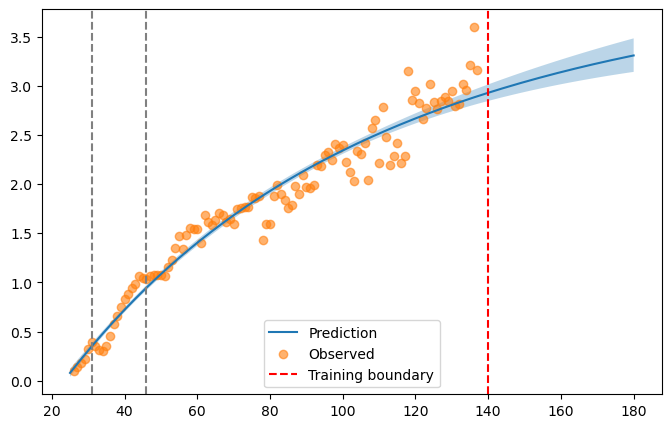

In [ ]:
# 检测模型外推结果
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(result['age'], result['food_e'], label='Prediction')
plt.fill_between(
    result['age'],
    result['lower_85'],
    result['upper_85'],
    alpha=0.3
)
plt.axvline(31, color='gray', linestyle='--')
plt.axvline(46, color='gray', linestyle='--')

plt.scatter(df['total_age'], y, alpha=0.6, label="Observed")
plt.axvline(140, color='red', linestyle='--', label='Training boundary')
plt.legend()
plt.show()


In [ ]:
# df.head()

## 3. 残差相关性 - 直观时序图

In [ ]:
color_map_event = {
    1: 'green',
    2: 'purple',
    3: 'orange',
    4: 'blue',
    # 5: '',
    9: 'black',
    -1: 'yellow',

}
type_map_event = {
    1: '发白',
    2: '呼吸道疾病',
    3: '应激',
    4: '胀气',
    # 5: 'purple',
    9: '猝死',

    -1: '治疗'
}
used_labels = set()

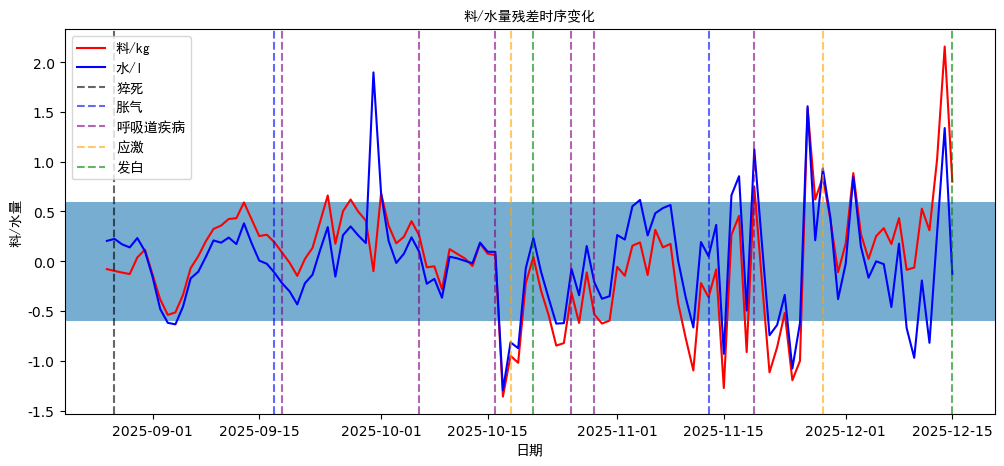

In [ ]:
df['food_resi'] = df['avg_food_kg'] - df['food_fit']
df['water_resi'] = df['avg_water_l'] - df['water_fit']

plt.figure(figsize=(12, 5))
plt.plot(df['Date'], df['food_resi']*3, color = 'red', label='料/kg')
plt.plot(df['Date'], df['water_resi'], color = 'blue', label='水/l')

used_labels = set()

for x in x_mask:
    event_type = df.loc[df['Date'] == x, 'Type'].iloc[0]    # 意外编号（int）
    event_legend = type_map_event[event_type]       # 意外类型（str）
    color = color_map_event.get(event_type, 'black')

    label = event_legend if event_legend not in used_labels else None
    used_labels.add(event_legend)

    plt.axvline(
        x,
        color=color,
        linestyle='--',
        alpha=0.6,
        label=label,
        
    )
# 添加残差参考区间
plt.axhspan(-0.6, 0.6, alpha=0.6)

# 图坐标轴绘制
plt.xlabel('日期', fontproperties=CN_font)
plt.ylabel('料/水量', fontproperties=CN_font)
plt.title('料/水量残差时序变化', fontproperties=CN_font)
plt.legend(prop = CN_font)
plt.show()

定量计算

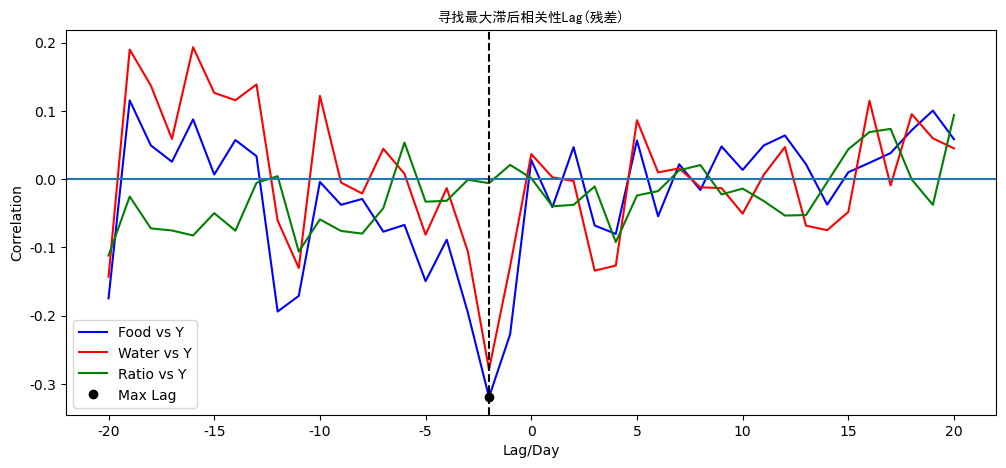

In [ ]:
def lagged_corr(x, y, max_lag=20):
    """
    x 和 y 在 [-max_lag, max_lag] 范围内的滞后相关性
    """
    lags = range(-max_lag, max_lag + 1)
    corrs = []

    for lag in lags:
        corr = x.shift(lag).corr(y, method='spearman')
        corrs.append(corr)
    
    return pd.Series(corrs, index=lags)

lag_A_Y = lagged_corr(df['food_resi'], df['y_bool'])
lag_B_Y = lagged_corr(df['water_resi'], df['y_bool'])
lag_C_Y = lagged_corr(df['Ratio'], df['y_bool'])

# 绘制整体lag曲线
plt.figure(figsize=(12,5))
plt.plot(lag_A_Y.index, lag_A_Y.values, color = 'blue', label='Food vs Y')
plt.plot(lag_B_Y.index, lag_B_Y.values, color = 'red', label='Water vs Y')
plt.plot(lag_C_Y.index, lag_C_Y.values, color = 'green', label='Ratio vs Y')
plt.axhline(0)
plt.xlabel("Lag/Day")
plt.ylabel("Correlation")


# 绘制最大点
max_id = abs(lag_A_Y).idxmax()
max_value = lag_A_Y[max_id]
plt.plot(max_id, max_value, 'o', color='black', label='Max Lag')
plt.axvline(max_id, linestyle='--', color='black')
plt.title('寻找最大滞后相关性Lag(残差)', fontproperties = CN_font)
plt.legend()
plt.show()

定量计算 - 残差取绝对值

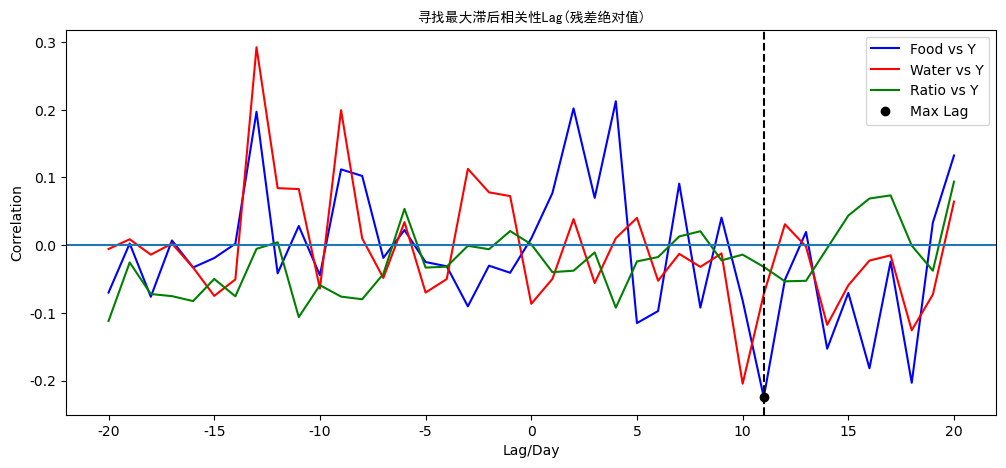

In [ ]:
# def lagged_corr(x, y, max_lag=20):
#     """
#     x 和 y 在 [-max_lag, max_lag] 范围内的滞后相关性
#     """
#     lags = range(-max_lag, max_lag + 1)
#     corrs = []

#     for lag in lags:
#         corr = x.shift(lag).corr(y, method='spearman')
#         corrs.append(corr)
    
#     return pd.Series(corrs, index=lags)

lag_A_Y = lagged_corr(abs(df['food_resi']), df['y_bool'])
lag_B_Y = lagged_corr(abs(df['water_resi']), df['y_bool'])
lag_C_Y = lagged_corr(abs(df['Ratio']), df['y_bool'])

# 绘制整体lag曲线
plt.figure(figsize=(12,5))
plt.plot(lag_A_Y.index, lag_A_Y.values, color = 'blue', label='Food vs Y')
plt.plot(lag_B_Y.index, lag_B_Y.values, color = 'red', label='Water vs Y')
plt.plot(lag_C_Y.index, lag_C_Y.values, color = 'green', label='Ratio vs Y')
plt.axhline(0)
plt.xlabel("Lag/Day")
plt.ylabel("Correlation")


# 绘制最大点
max_id = abs(lag_A_Y).idxmax()
max_value = lag_A_Y[max_id]
plt.plot(max_id, max_value, 'o', color='black', label='Max Lag')
plt.axvline(max_id, linestyle='--', color='black')
plt.title('寻找最大滞后相关性Lag(残差绝对值)', fontproperties = CN_font)
plt.legend()
plt.show()

## 4. 拟合曲线vs饲喂标准

In [ ]:
import pandas as pd

hn_df = pd.read_excel('data/河南-饲料饲喂标准.xlsx', index_col=False)
fit_df = pd.read_excel('data/std_food_table_log_log.xlsx', index_col=False)

df = pd.merge(hn_df, fit_df, on='age')

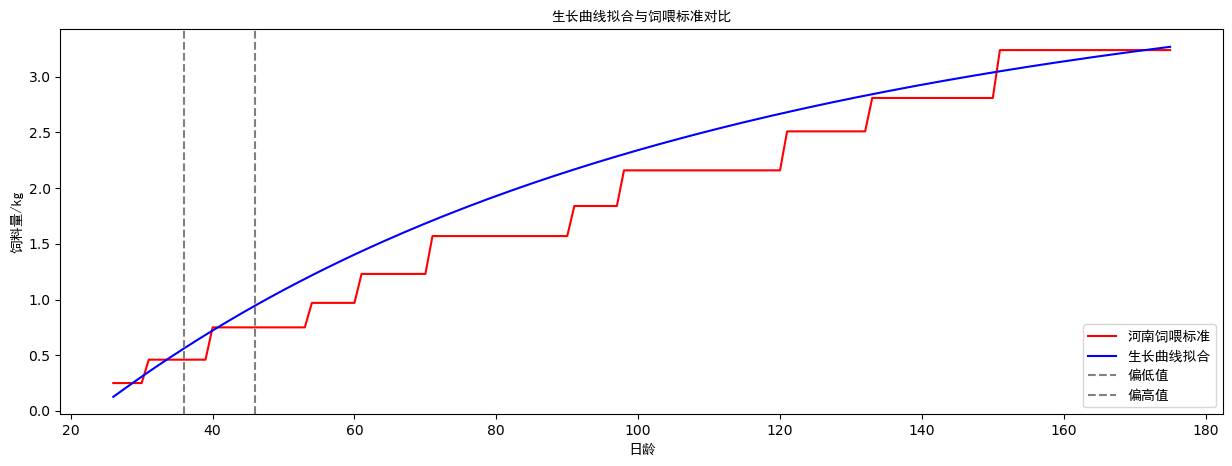

In [ ]:
import matplotlib.pyplot as plt
from matplotlib import font_manager

CN_font = font_manager.FontProperties(fname='C:/Windows/Fonts/simhei.ttf')

plt.figure(figsize=(15,5))
plt.plot(df['age'], df['std_food'], color='red', label='河南饲喂标准')
plt.plot(df['age'], df['food_e'], color='blue', label='生长曲线拟合')

plt.axvline(36, color='gray', linestyle='--', label='偏低值')
plt.axvline(46, color='gray', linestyle='--', label='偏高值')

plt.xlabel('日龄', fontproperties=CN_font)
plt.ylabel('饲料量/kg', fontproperties=CN_font)
plt.title("生长曲线拟合与饲喂标准对比", fontproperties=CN_font)
plt.legend(prop = CN_font)
plt.show()

## 5 料肉比

### 5.1 实际vs拟合

In [ ]:
import pandas as pd

df = pd.read_excel('data/4栋2单元-初步处理.xlsx', sheet_name = 'Sheet1', skiprows=3).iloc[::-1, :][['饲喂日期', '均采食量/kg', '总日龄']]
fit_df = pd.read_excel('data/std_food_table_log_log.xlsx', index_col=False)

FCR = 2.65
df['饲喂日期'] = pd.to_datetime(df['饲喂日期'])

df['实际应增重'] = df['均采食量/kg'] / FCR
df['实际推测重量'] = df['实际应增重'].cumsum()  + 14  # 假设初始体重为14kg
df = df.merge(fit_df, left_on='总日龄', right_on='age', how='left')

df['拟合应增重'] = df['food_e'] / FCR
df['拟合推测重量'] = df['拟合应增重'].cumsum()  + 14  # 假设初始体重为14kg

df['体重差值'] = df['实际推测重量'] - df['拟合推测重量']

# df.to_excel('data/四栋2单元推测重量统计.xlsx', index=False) # 保存备用

拟合值和实际推测日龄重量曲线对比

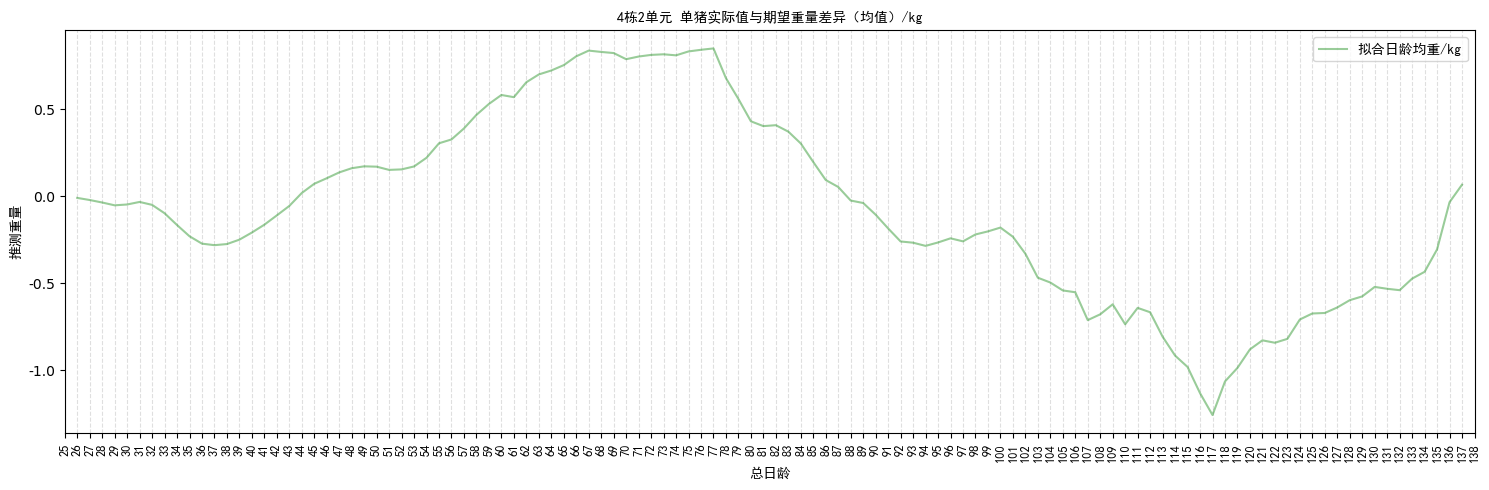

In [ ]:
import matplotlib.pyplot as plt
from matplotlib import font_manager
import matplotlib.dates as mdates
from matplotlib.ticker import MultipleLocator

CN_font = font_manager.FontProperties(fname='C:/Windows/Fonts/simhei.ttf')

plt.figure(figsize=(15,5))
# plt.plot(df['总日龄'], df['实际推测重量'], color='red', label='实际日龄均重/kg', alpha=0.4)
# plt.plot(df['总日龄'], df['拟合推测重量'], color='blue', label='拟合日龄均重/kg', alpha=0.4)
plt.plot(df['总日龄'], df['体重差值'], color='green', label='拟合日龄均重/kg', alpha=0.4)
# plt.plot(fit_df['age'], fit_df['food_e']*25, color='green', label='饲喂曲线拟合/kg (25倍)')

ax = plt.gca()
ax.xaxis.set_major_locator(MultipleLocator(1)) # x 轴刻度间隔 = 1
ax.grid(axis='x', linestyle='--', alpha=0.4)

plt.xlabel('总日龄', fontproperties=CN_font)
plt.ylabel('推测重量', fontproperties=CN_font)
plt.title("4栋2单元 单猪实际值与期望重量差异（均值）/kg", fontproperties=CN_font)

plt.xticks(rotation=90, fontproperties=CN_font, fontsize=9)
plt.xlim(25, max(df['总日龄'])+1)
plt.legend(prop=CN_font)
plt.tight_layout()
plt.savefig('figure/4栋2单元单猪实际值与期望重量差异-kg.png', dpi=300)
plt.show()

### 5.2 拟合值（扩展）

In [ ]:
import pandas as pd

FCR = 2.65
fit_df = pd.read_excel('data/std_food_table_log_log.xlsx', index_col=False)[['age', 'food_e']]

fit_df['实际应增重'] = fit_df['food_e'] / FCR
fit_df['实际推测重量'] = fit_df['实际应增重'].cumsum()  + 14  # 假设初始体重为14kg

拟合值和实际推测日龄重量曲线对比

In [ ]:
import matplotlib.pyplot as plt
from matplotlib import font_manager
import matplotlib.dates as mdates
from matplotlib.ticker import MultipleLocator

CN_font = font_manager.FontProperties(fname='C:/Windows/Fonts/simhei.ttf')

plt.figure(figsize=(15,6))
plt.plot(fit_df['age'], fit_df['实际推测重量'], color='red', label='拟合日龄均重/kg', alpha=0.4)
plt.axvline(180, color='gray', linestyle='--', label='出栏时间')
plt.
ax = plt.gca()
# x 轴刻度间隔 = 1
ax.xaxis.set_major_locator(MultipleLocator(1))
# 添加 x 轴虚线（竖向网格线）
ax.grid(axis='x', linestyle='--', alpha=0.4)

plt.xlabel('总日龄', fontproperties=CN_font)
plt.ylabel('推测重量', fontproperties=CN_font)
plt.title("单猪期望重量/kg", fontproperties=CN_font)

plt.xticks(rotation=90, fontproperties=CN_font, fontsize=9)
plt.xlim(25, 185)
plt.legend(prop=CN_font)
plt.tight_layout()
plt.savefig('figure/单猪期望重量(kg).png', dpi=300)
plt.show()

SyntaxError: invalid syntax (685008984.py, line 11)

## 6 采用三栋数据进行拟合

三栋总体数据&存栏量

### 6.1 模型拟合

In [ ]:
import pandas as pd

# 总料量数据
df = pd.read_excel('data/三栋1-4单元总量统计.xlsx', index_col=False)[['饲喂日期', '单元均值']]
df['总量'] = df['单元均值'] * 4  # 转换为总量
df['饲喂日期'] = pd.to_datetime(df['饲喂日期'])

# 总存栏数据
df_n = pd.read_excel('data/三栋总存栏数据.xlsx', index_col=False).dropna(axis=1, how='all').rename(columns={'日期': '饲喂日期'})
df_n['饲喂日期'] = pd.to_datetime(df_n['饲喂日期'])

df['总日龄'] = ((df['饲喂日期'] - pd.to_datetime('2025-08-28')).dt.days) + 32  # 添加日龄列
df = df.merge(df_n, on='饲喂日期') # 关联存栏数据
df['只均料量'] = df['总量'] / df['存栏']  # 计算只均料量

                            OLS Regression Results                            
Dep. Variable:                   只均料量   R-squared:                       0.967
Model:                            OLS   Adj. R-squared:                  0.967
Method:                 Least Squares   F-statistic:                     1487.
Date:                Sun, 04 Jan 2026   Prob (F-statistic):           4.18e-75
Time:                        10:22:29   Log-Likelihood:                 154.98
No. Observations:                 103   AIC:                            -304.0
Df Residuals:                     100   BIC:                            -296.1
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.0026      0.005    186.557      0.0

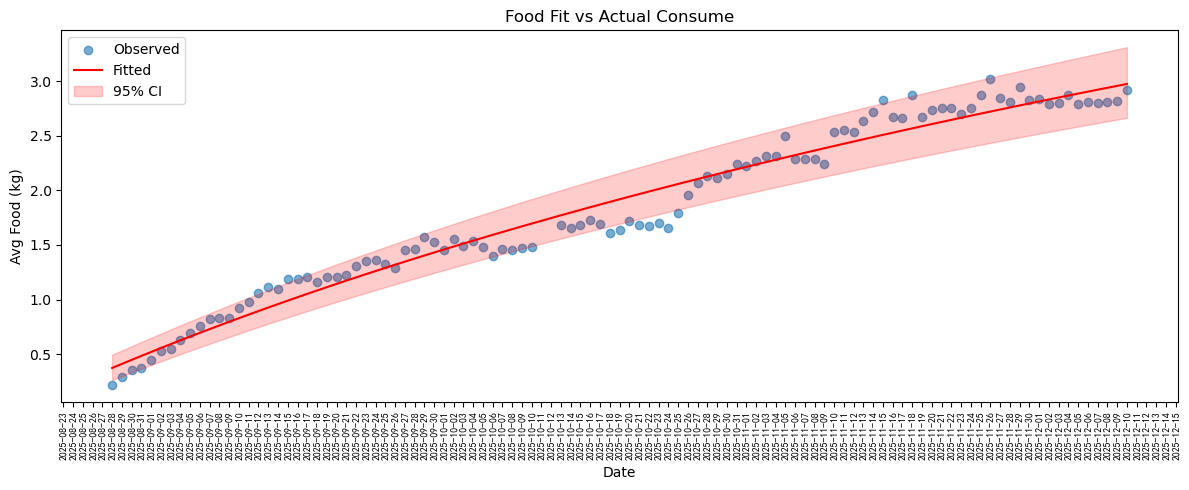

In [ ]:
# 采用log-log多项式二阶数据拟合
import numpy as np
import statsmodels.api as sm
from sklearn.preprocessing import PolynomialFeatures

X = df[['总日龄']].copy()
X['log_age'] = np.log(X['总日龄'] + 1e-6)
X = X[['log_age']]  

y = df['只均料量']
y_log = np.log1p(y)  # 对数转换

# 生成多项式特征（degree=2 或 3）
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X)

# 标准化
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_poly_scaled = scaler.fit_transform(X_poly)

# statsmodels 回归
X_poly_sm = sm.add_constant(X_poly_scaled)
model_poly = sm.OLS(y_log, X_poly_sm).fit()
print(model_poly.summary())

pred = model_poly.get_prediction(X_poly_sm)
pred_summary = pred.summary_frame(alpha=0.15)
print(model_poly.summary())

smearing = np.mean(np.exp(model_poly.resid))

df["food_fit"] = smearing * np.expm1(pred_summary["mean"])
df["ci_lower"] = smearing * np.expm1(pred_summary["mean_ci_lower"])
df["ci_upper"] = smearing * np.expm1(pred_summary["mean_ci_upper"])

df["pred_lower_food"] = smearing * np.expm1(pred_summary["obs_ci_lower"])  # 预测区间下界
df["pred_upper_food"] = smearing * np.expm1(pred_summary["obs_ci_upper"])  # 预测区间上界

# 输出评估指标
# Pseudo R-squared calculation
y_true = df['只均料量'].values
y_pred = df['food_fit'].values  # 已经 expm1 + smearing 后的

ss_res = np.sum((y_true - y_pred) ** 2)
ss_tot = np.sum((y_true - y_true.mean()) ** 2)

r2_orig = 1 - ss_res / ss_tot
print("Pseudo R² (original scale):", r2_orig)
print("Residual variance (log-space):", np.var(model_poly.resid))

rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
mae = np.mean(np.abs(y_true - y_pred))

print("RMSE:", rmse)
print("MAE:", mae)


## 绘制对应图像
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib import font_manager
CN_font = font_manager.FontProperties(fname='C:/Windows/Fonts/simhei.ttf')

plt.figure(figsize=(12,5))
plt.scatter(df['饲喂日期'], y, alpha=0.6, label="Observed")
plt.plot(df['饲喂日期'], df['food_fit'], color='red', label="Fitted")
plt.fill_between(
    df['饲喂日期'],
    df['pred_lower_food'],
    df['pred_upper_food'],
    color='red',
    alpha=0.2,
    label="95% CI"
)

plt.legend()
plt.xlabel("Date")
plt.ylabel("Avg Food (kg)")
plt.title('Food Fit vs Actual Consume')

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))

plt.xticks(rotation=90, fontproperties=CN_font, fontsize=7)
plt.legend()
plt.tight_layout()
plt.show()

### 6.2 检测数据外推

In [ ]:
new_age = np.arange(25, 181, 1)
X_new = pd.DataFrame({'age': new_age})
X_new['log_age'] = np.log(X_new['age'] + 1e-6)
X_new = X_new[['log_age']]

# 多项式变换-标准化-加常数
X_new_poly = poly.transform(X_new)
X_new_poly_scaled = scaler.transform(X_new_poly)
X_new_poly_sm = sm.add_constant(X_new_poly_scaled)

pred_log = model_poly.get_prediction(X_new_poly_sm)
pred_log_summary = pred_log.summary_frame(alpha=0.15)
# print(pred_log_summary.head())

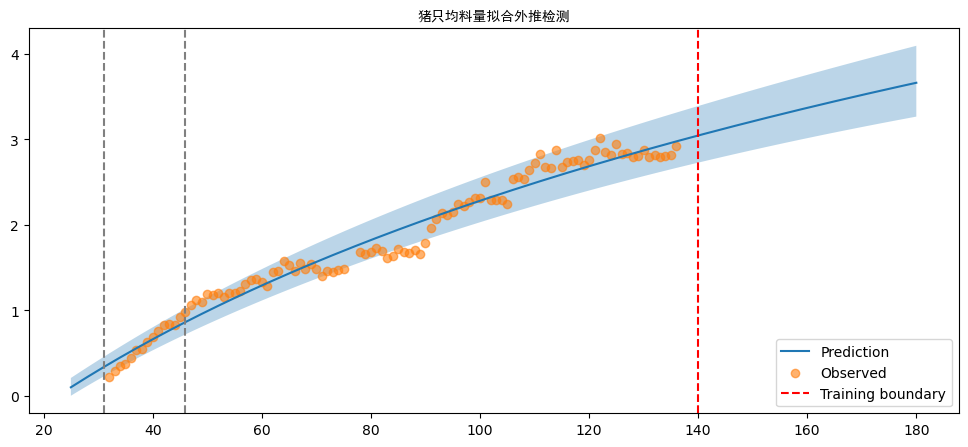

In [ ]:
# 还原尺度
pred_mean = smearing * np.expm1(pred_log_summary["mean"])
pred_lower = smearing * np.expm1(pred_log_summary["obs_ci_lower"])
pred_upper = smearing * np.expm1(pred_log_summary["obs_ci_upper"])

result = pd.DataFrame({
    'age': new_age,
    'food_e': pred_mean,
    'lower_85': pred_lower,
    'upper_85': pred_upper
})

result.to_excel('data/std_food_table_log_log_3.xlsx', index=False)

# 检测模型外推结果
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(result['age'], result['food_e'], label='Prediction')
plt.fill_between(
    result['age'],
    result['lower_85'],
    result['upper_85'],
    alpha=0.3
)
plt.axvline(31, color='gray', linestyle='--')
plt.axvline(46, color='gray', linestyle='--')

plt.scatter(df['总日龄'], y, alpha=0.6, label="Observed")
plt.axvline(140, color='red', linestyle='--', label='Training boundary')
plt.title('猪只均料量拟合外推检测', fontproperties=CN_font)
plt.legend()
plt.show()


### 6.3 三/四栋拟合曲线 vs 饲喂标准

In [ ]:
import pandas as pd

hn_df = pd.read_excel('data/河南-饲料饲喂标准.xlsx', index_col=False)
fit4_df = pd.read_excel('data/std_food_table_log_log.xlsx', index_col=False) # 4栋2单元拟合结果
fit3_df = pd.read_excel('data/std_food_table_log_log_3.xlsx', index_col=False) # 3栋拟合结果

# 重新命名
key = 'age'
fit4_df = fit4_df.rename(columns={c: c+'_fit4' for c in fit4_df.columns if c != key})
fit3_df = fit3_df.rename(columns={c: c+'_fit3' for c in fit3_df.columns if c != key})

# 合并数据框
df = pd.merge(hn_df, fit4_df, on='age')
df = pd.merge(df, fit3_df, on='age')

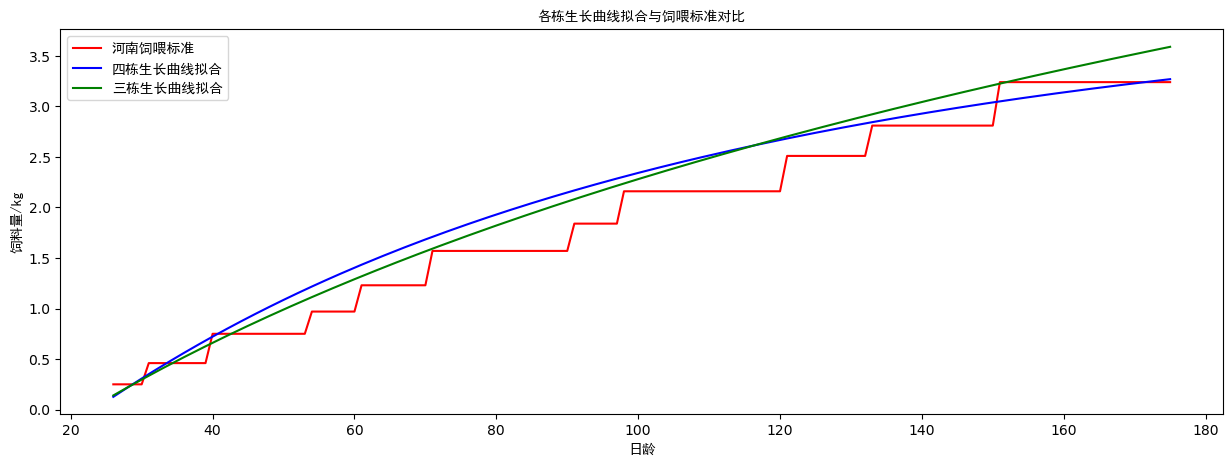

In [ ]:
import matplotlib.pyplot as plt
from matplotlib import font_manager
import matplotlib.ticker as mticker

CN_font = font_manager.FontProperties(fname='C:/Windows/Fonts/simhei.ttf')

plt.figure(figsize=(15,5))
plt.plot(df['age'], df['std_food'], color='red', label='河南饲喂标准')
plt.plot(df['age'], df['food_e_fit4'], color='blue', label='四栋生长曲线拟合')
plt.plot(df['age'], df['food_e_fit3'], color='green', label='三栋生长曲线拟合')

# plt.axvline(36, color='gray', linestyle='--', label='偏低值')
# plt.axvline(46, color='gray', linestyle='--', label='偏高值')

plt.xlabel('日龄', fontproperties=CN_font)
plt.ylabel('饲料量/kg', fontproperties=CN_font)
ax = plt.gca()
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True, prune='both'))
plt.title("各栋生长曲线拟合与饲喂标准对比", fontproperties=CN_font)
plt.legend(prop = CN_font)
plt.show()

## 7 三栋 四栋生长实际对比

In [ ]:
import pandas as pd

# 三栋总料量数据
df = pd.read_excel('data/三栋1-4单元总量统计.xlsx', index_col=False)[['饲喂日期', '单元均值']]
df['总量'] = df['单元均值'] * 4  # 转换为总量
df['饲喂日期'] = pd.to_datetime(df['饲喂日期'])

# 三栋总存栏数据
df_n = pd.read_excel('data/三栋总存栏数据.xlsx', index_col=False).dropna(axis=1, how='all').rename(columns={'日期': '饲喂日期'})
df_n['饲喂日期'] = pd.to_datetime(df_n['饲喂日期'])

df['总日龄'] = ((df['饲喂日期'] - pd.to_datetime('2025-08-28')).dt.days) + 32  # 添加日龄列
df = df.merge(df_n, on='饲喂日期') # 关联存栏数据
df['只均料量'] = df['总量'] / df['存栏']  # 计算只均料量

# 四栋总料量数据
df_4 = pd.read_excel('data/4栋2单元-初步处理.xlsx', sheet_name = 'Sheet1', skiprows=3).rename(
    columns={'饲喂日期': 'Date', 
                        '每日采食总量(Kg)': 'Food/kg', 
                        '每日喂水总量(L)': 'Water/L', 
                        '水料比': 'Ratio', 
                        '死亡数': 'n_case',
                        '事故类型': 'Type',
                        '转舍前日龄':'before_age', 
                        '转舍日龄':'after_age', 
                        '总日龄': 'total_age', 
                        '存栏数': 'num',
                        '均采食量/kg': 'avg_food_kg', 
                        '均喂水量/L': 'avg_water_l', 
                        '应采食量/kg': 'reg_food_kg', 
                        '是否治疗': 'if_cure'
                        })


In [ ]:
# import matplotlib.pyplot as plt
# from matplotlib import font_manager
# from matplotlib.ticker import MultipleLocator

# CN_font = font_manager.FontProperties(fname='C:/Windows/Fonts/simhei.ttf')
# plt.figure(figsize=(12,5))

# plt.scatter(df['总日龄'], df['只均料量'], alpha=0.4, color='red', label="三栋均值 日龄对应只均料量")
# plt.scatter(df_4['total_age'], df_4['avg_food_kg'], alpha=0.4, color='blue', label="四栋2单元 日龄对应只均料量")

# ax = plt.gca()
# ax.xaxis.set_major_locator(MultipleLocator(5))
# plt.title('猪只均料量拟合外推检测', fontproperties=CN_font)
# plt.xlabel('日龄', fontproperties=CN_font)
# plt.legend(prop=CN_font)
# plt.show()

In [ ]:
# 筛选合适数据
df_plot = pd.concat([
    df.assign(
        building='三栋均值',
        total_age=df['总日龄'],
        avg_food_kg=df['只均料量'],
        date=df['饲喂日期'].dt.date,
    )[['building', 'total_age', 'avg_food_kg', 'date']],

    df_4.assign(
        building='四栋2单元',
        total_age=(pd.to_datetime(df_4['Date']) - pd.to_datetime('2025-08-25')).dt.days + 23,
        avg_food_kg=df_4['avg_food_kg'],
        date=df_4['Date'],
    )[['building', 'total_age', 'avg_food_kg', 'date']]
    ]
)

In [ ]:
import plotly.express as px

fig = px.scatter(
    df_plot,
    x='total_age',
    y='avg_food_kg',
    color='building', symbol='building',
    opacity=0.5,
    title='猪只均料量-三栋均值与四栋2单元',
    hover_data={
        'total_age': True,
        'avg_food_kg': ':.3f',
        'date': ':%Y-%m-%d',
    }
)

tickvals = df['总日龄'][::3]
fig.update_xaxes(title='总日龄/天', tickvals=tickvals, ticktext=tickvals, tickangle=-45)
fig.update_yaxes(title='只均料量/kg')

fig.write_html('figure/猪只均料量对比.html', include_plotlyjs='cdn', full_html=True)
fig.show()

# 8 四栋生长曲线解释

In [ ]:
from
df_34_build = pd.read_parquet(PATH_FEED_PROCESSED / '育肥3-4_build.parquet', engine='pyarrow').drop_duplicates()

In [ ]:
df_4 = pd.read_excel('data/4栋2单元-初步处理.xlsx', sheet_name = 'Sheet1', skiprows=3).rename(
    columns={'饲喂日期': 'Date', 
                        '每日采食总量(Kg)': 'Food/kg', 
                        '每日喂水总量(L)': 'Water/L', 
                        '水料比': 'Ratio', 
                        '死亡数': 'n_case',
                        '事故类型': 'Type',
                        '转舍前日龄':'before_age', 
                        '转舍日龄':'after_age', 
                        '总日龄': 'total_age', 
                        '存栏数': 'num',
                        '均采食量/kg': 'avg_food_kg', 
                        '均喂水量/L': 'avg_water_l', 
                        '应采食量/kg': 'reg_food_kg', 
                        '是否治疗': 'if_cure'
                        })